### My final project: Snowfall to water flow

My goal is to know how much water is in the snowpack and how much is going into our water supply. Snowpack is basically a natural water storage system. During the winter, snow builds up in the mountains, and when it melts in the spring and summer, it becomes the water that flows into rivers like Boulder Creek. Knowing how much water is in that snowpack is important because it helps us predict how much water we’ll have later in the year and whether there could be flooding or drought. This project shows how this is calculated matters because it makes the process easier to understand and trust. It helps connect the snow in the mountains to the water we actually use, which is especially important as climate change starts to affect how much snow we get and when it melts. I will be showing the snowpack/SWE mesurment sand stream flow data for the boudler watershed. As this project evolves I might be adding adisional data like tempature and precipitation data.  

Library download 

In [14]:
### reproducible file paths li
import os

### serializing and unserializing objects
import pickle

### regular expressions
import re

### warnings control
import warnings

### projecting and mapping
import cartopy.crs as ccrs

### access satellite data
import earthaccess

### spatial data management
import earthpy as et

### vector and shapefile 
import geopandas as gpd

### visualizations
import geoviews as gv

### visualization 
import hvplot.pandas
import hvplot.xarray

### arrays
import numpy as np

### tables
import pandas as pd

### rasters
import rioxarray as rxr
import rioxarray.merge as rxrmerge
import xarray as xr

### progress bars
from tqdm.notebook import tqdm

### polygons
from shapely.geometry import Polygon

### kmeans clustering
from sklearn.cluster import KMeans

### set GDAL parameters
os.environ["GDAL_HTTP_MAX_RETRY"] = "5"
os.environ["GDAL_HTTP_RETRY_DELAY"] = "1"

### don't show non-critical warnings
warnings.simplefilter('ignore')

Download boundary of the Colorado Head Waters , show Map of Boundary 

In [15]:
import geopandas as gpd
from urllib.parse import urlencode

### Colorado Headwaters watershed 
HUC8 = "14010001"

# USGS WBD HUC12 layer
base_url = "https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/6/query"

# Step 1: get all HUC12s in Colorado Headwaters basin
params = {
    "where": f"huc12 LIKE '{HUC8}%'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

query_url = f"{base_url}?{urlencode(params)}"
print("Query URL:", query_url)

# Load into GeoDataFrame
gdf = gpd.read_file(query_url)

print("Loaded features:", len(gdf))
print("Columns:", gdf.columns)

# Step 2: (optional) inspect basin contents
print(gdf[['huc12', 'name']].head())

# Step 3: Save full Colorado Headwaters basin
output_name = "colorado_headwaters_huc12.shp"
gdf.to_file(output_name)

print(f"Saved as {output_name}")

Query URL: https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/6/query?where=huc12+LIKE+%2714010001%25%27&outFields=%2A&returnGeometry=true&f=geojson
Loaded features: 86
Columns: Index(['objectid', 'tnmid', 'metasourceid', 'sourcedatadesc',
       'sourceoriginator', 'sourcefeatureid', 'loaddate', 'referencegnis_ids',
       'areaacres', 'areasqkm', 'states', 'huc12', 'name', 'hutype', 'humod',
       'tohuc', 'noncontributingareaacres', 'noncontributingareasqkm',
       'globalid', 'shape_Length', 'shape_Area', 'geometry'],
      dtype='object')
          huc12                              name
0  140100011003           Headwaters Egeria Creek
1  140100010709                Outlet Muddy Creek
2  140100010701  Diamond Creek-Little Muddy Creek
3  140100010407               Lower Williams Fork
4  140100010702            Headwaters Muddy Creek
Saved as colorado_headwaters_huc12.shp


<Axes: >

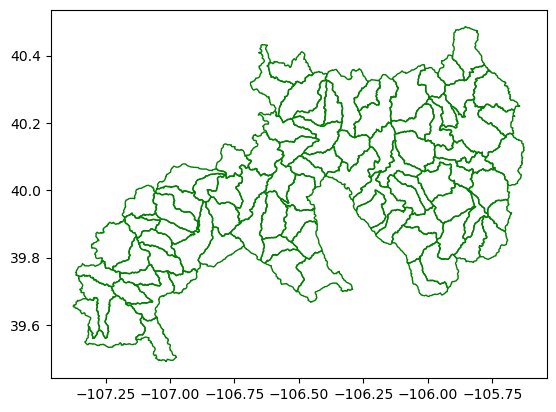

In [16]:
gdf.plot(edgecolor='green', facecolor='none')

Snow Water Equivalent for the head waters 

In [17]:
df = pd.read_csv("colorado_headwaters.csv")
print(df.head())

    date      1986   1987  1988  1989  1990      1991  1992  1993      1994  \
0  10-01  0.368421  1.005   0.0   0.0   0.0  0.000000   0.0   0.0  0.000000   
1  10-02  0.268421  1.030   0.0   0.0   0.0  0.000000   0.0   0.0  0.000000   
2  10-03  0.215789  1.160   0.0   0.0   0.0  0.047619   0.0   0.0  0.004545   
3  10-04  0.163158  1.340   0.0   0.0   0.0  0.014286   0.0   0.0  0.004545   
4  10-05  0.131579  1.265   0.0   0.0   0.0  0.019048   0.0   0.0  0.009091   

   ...      2026  10%  30%       70%       90%  Min  Median ('91-'20)  \
0  ...  0.000000  0.0  0.0  0.014801  0.181814  0.0               0.0   
1  ...  0.000000  0.0  0.0  0.022559  0.200635  0.0               0.0   
2  ...  0.000000  0.0  0.0  0.050333  0.162202  0.0               0.0   
3  ...  0.000000  0.0  0.0  0.066270  0.166842  0.0               0.0   
4  ...  0.006452  0.0  0.0  0.051457  0.344698  0.0               0.0   

   Median (POR)       Max  Median Peak SWE  
0      0.000000  1.005000              Na

Separate blank spaces 

In [18]:
### check for missing values
print(df.isnull().sum())

date                  0
1986                  1
1987                  1
1988                  0
1989                  1
1990                  1
1991                  1
1992                  0
1993                  1
1994                  1
1995                  1
1996                  0
1997                  1
1998                  1
1999                  1
2000                  0
2001                  1
2002                  1
2003                  1
2004                  0
2005                  1
2006                  1
2007                  1
2008                  0
2009                  1
2010                  1
2011                  1
2012                  0
2013                  1
2014                  1
2015                  1
2016                  0
2017                  1
2018                  1
2019                  1
2020                  0
2021                  1
2022                  1
2023                  1
2024                  0
2025                  1
2026            

Just show Boulder Watershed, Downsize and find a more efficient way to show my knowledge. 

Query URL: https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/6/query?where=huc12+LIKE+%2710190005%25%27&outFields=%2A&returnGeometry=true&f=geojson
Number of HUC12s: 35
Saved as boulder_watershed_boundary.shp


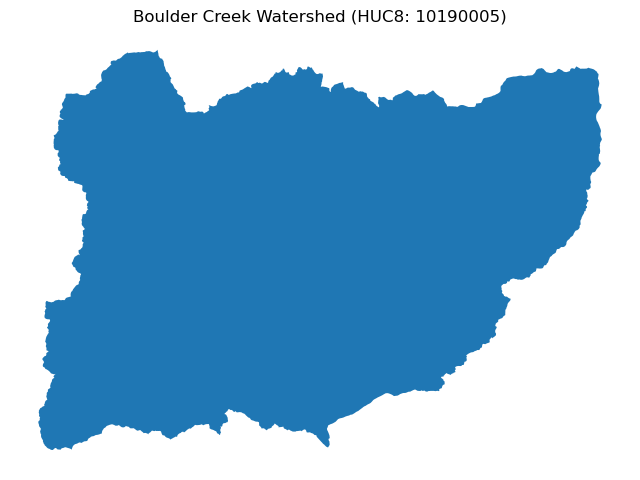

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from urllib.parse import urlencode

# Boulder Creek Watershed
HUC8 = "10190005"

# USGS Watershed Boundary Dataset (HUC12 layer)
base_url = "https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/6/query"

params = {
    "where": f"huc12 LIKE '{HUC8}%'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

# Build query URL
query_url = f"{base_url}?{urlencode(params)}"
print("Query URL:", query_url)

# Load data
gdf = gpd.read_file(query_url)

print("Number of HUC12s:", len(gdf))

#  Dissolve into one watershed boundary 
watershed = gdf.dissolve()

# Save shapefile 
watershed.to_file("boulder_watershed_boundary.shp")

print("Saved as boulder_watershed_boundary.shp")

# Plot 
fig, ax = plt.subplots(figsize=(8, 8))

watershed.plot(ax=ax)
ax.set_title("Boulder Creek Watershed (HUC8: 10190005)")
ax.set_axis_off()

plt.show()

Put the boundary over a satellite image 

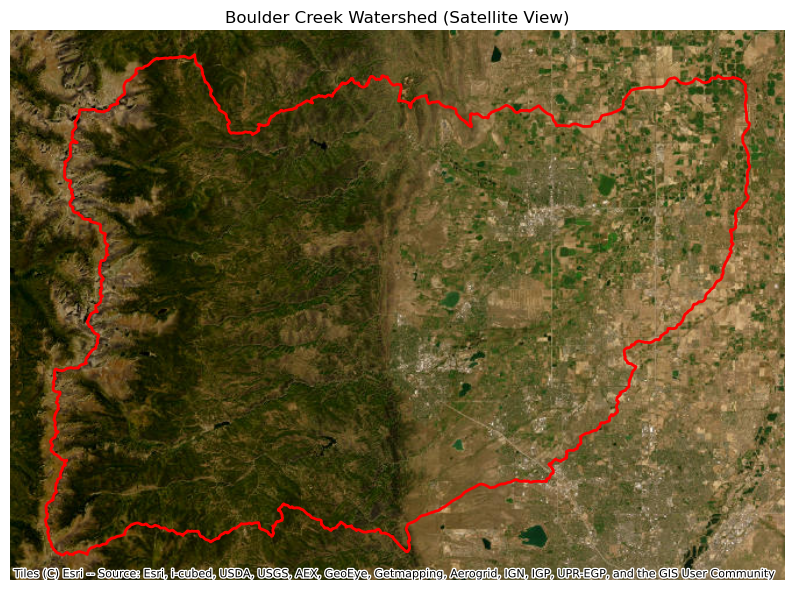

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from urllib.parse import urlencode

# Boulder Creek Watershed
HUC8 = "10190005"

base_url = "https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer/6/query"

params = {
    "where": f"huc12 LIKE '{HUC8}%'",
    "outFields": "*",
    "returnGeometry": "true",
    "f": "geojson"
}

query_url = f"{base_url}?{urlencode(params)}"

# Load data
gdf = gpd.read_file(query_url)

# Dissolve into one boundary
watershed = gdf.dissolve()

# IMPORTANT: Reproject to Web Mercator 
watershed = watershed.to_crs(epsg=3857)

# Plot 
fig, ax = plt.subplots(figsize=(10, 10))

watershed.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

# Add satellite basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery
)

ax.set_title("Boulder Creek Watershed (Satellite View)")
ax.set_axis_off()

plt.show()

Bring in steam gage data, continue to check in with LTER about this years data. I wont see the worst flow rates until later into the summer.

In [21]:
import dataretrieval.nwis as nwis
import pandas as pd

# USGS site info
site = "06730200"   # Boulder Creek stream gage
parameter = "00060" # Streamflow (discharge in cubic feet per second)

# Time range 
start = "2020-01-01"
end = "2024-12-31"

# Download data
df = nwis.get_record(
    sites=site,
    service="dv",   # daily values
    parameterCd=parameter,
    start=start,
    end=end
)

# Preview
print(df.head())

# Save to CSV
df.to_csv("boulder_streamflow.csv")

print("Saved as boulder_streamflow.csv")

                            site_no  00060_Mean 00060_Mean_cd
datetime                                                     
2020-01-01 00:00:00+00:00  06730200        22.0             A
2020-01-02 00:00:00+00:00  06730200        20.2             A
2020-01-03 00:00:00+00:00  06730200        18.1             A
2020-01-04 00:00:00+00:00  06730200        18.5             A
2020-01-05 00:00:00+00:00  06730200        18.5             A
Saved as boulder_streamflow.csv


Show example of stream gage data over the past few years. This gives a good view of how the snowmlet increases.

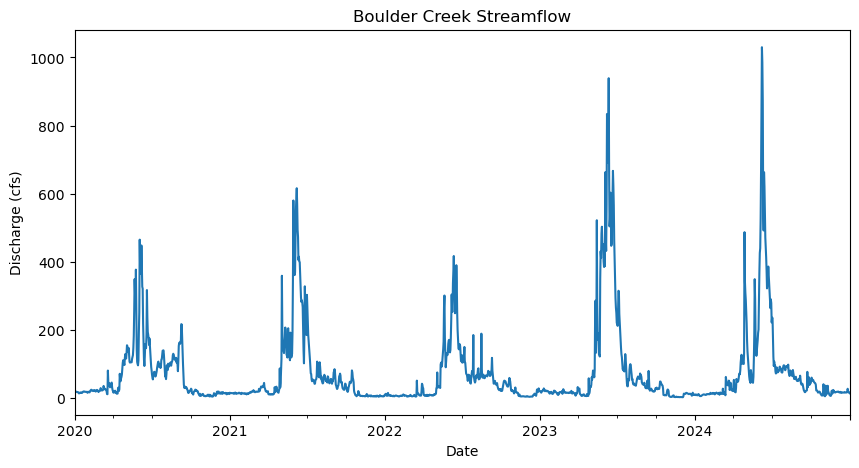

In [22]:
import matplotlib.pyplot as plt

df['00060_Mean'].plot(figsize=(10,5))
plt.title("Boulder Creek Streamflow")
plt.ylabel("Discharge (cfs)")
plt.xlabel("Date")
plt.show()

Looking ahead; bring in 2013 and as much of 2026 stream gage data as I can to show how devistating the lack of SWE there is this year. 